# Industry-Relative-Reversal -- does subtracting the sector make the reversal better?
### Hameed-Mian (2015) / Da-Liu-Schaumburg (2014), tested honestly on the S&P 500 tape

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Industry-adjustment beats raw: Confirmed](https://img.shields.io/badge/Industry_beats_raw-Confirmed-8b949e?style=flat-square)

The one-month reversal -- buy last month's losers, sell last month's winners -- is the most famous short-horizon anomaly in equities. But [Study 329](../../329-one-month-reversal/) found the *raw* version is mostly bid-ask bounce, dead since ~2002. Two papers (Hameed-Mian 2015; Da-Liu-Schaumburg 2014) say the trick is to measure the reversal **relative to each stock's own industry**: a stock's move splits into its *sector's* move (which does **not** reverse) and the part *unique to the stock* (which does). Subtract the sector first, and you should get a cleaner signal. This notebook asks whether that is true -- and whether 'cleaner' is enough to be tradable.

> Plain-language layer. The t-stats, the placebo, and the cost wall live in the companion **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** Reproducible research: every chart is drawn by the code beside it; real headline numbers are pinned in [docs/results.md](../docs/results.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from industry_relative_reversal import data, strategy as st

# Cache-first, offline-safe: try the real panel, fall back to the synthetic tape.
try:
    prices = data.load_real()
    sectors = data.sector_series(prices.columns)
    raw0 = st.quintile_returns(st.raw_signal(prices, skip=0), prices, q=0.20)
    irr0 = st.quintile_returns(st.industry_relative_signal(prices, sectors, skip=0), prices, q=0.20)
    raw1 = st.quintile_returns(st.raw_signal(prices, skip=1), prices, q=0.20)
    irr1 = st.quintile_returns(st.industry_relative_signal(prices, sectors, skip=1), prices, q=0.20)
    HAVE_REAL = True
    print(f"REAL tape loaded: {prices.shape[0]} months x {prices.shape[1]} tickers "
          f"({prices.index[0].date()} -> {prices.index[-1].date()}, fp {data.fingerprint(prices)})")
except Exception as exc:
    HAVE_REAL = False
    prices = sectors = raw0 = irr0 = raw1 = irr1 = None
    print("No real cache (offline) -- cells will run the SYNTHETIC tape and quote frozen R numbers.")
    print("  reason:", type(exc).__name__)

print("HAVE_REAL:", HAVE_REAL)


REAL tape loaded: 437 months x 54 tickers (1990-01-31 -> 2026-05-31, fp bbd55e07b990)
HAVE_REAL: True


## The answer first

| Question | Answer |
|---|---|
| Does subtracting the sector give a better signal? | **Yes.** The industry-relative spread (**+9.5** bps/mo) *flips the sign* of the raw spread (**-11.0** bps/mo) and beats it. |
| Is the 'industry' part doing real work? | **Yes.** Shuffle the sector labels and the advantage vanishes -- the real signal sits above the 99.5th percentile of the shuffled null (p = 0.005). |
| Is it statistically real (clears *t* = 2)? | **No.** The industry-relative *t* is only **+0.56** on this 54-name basket. Right direction, sub-bar magnitude. |
| Could you trade it? | **No.** ~77% turnover a month; break-even ~3.1 bps; costs turn it loss-making almost immediately. |

> The refinement *works as advertised* -- a cleaner signal than the raw reversal -- it is simply too faint, on a thin survivor basket, to clear the bar or to pay for its own turnover.

## 1 - The claim

> *'Stock return reversals are primarily driven by the within-industry component of returns. The across-industry (sector) component does not reverse.'*
> -- Hameed & Mian (2015), JFQA; Da, Liu & Schaumburg (2014), Management Science

Think of last month's return as two pieces:

- **The sector's move.** If all of energy rallied last month, ExxonMobil rallied partly *because it is energy*. That piece reflects real news and does **not** bounce back.
- **The stock's own move.** The part of Exxon's return *beyond* what energy did. *That* piece is where the overreaction -- and the reversal -- lives.

The raw reversal mixes the two, diluting the signal. The fix: rank stocks by their **industry-relative** return (stock minus its sector mean).

## 2 - So what?

If true, this is a genuinely better mousetrap: a market-neutral reversal that is not just bid-ask bounce (which is what sank the raw version in Study 329). It would be the difference between a famous-but-dead anomaly and a live, tradable, sector-neutral edge.

But 'a better signal' and 'a tradable strategy' are different claims. A one-month signal -- even a clean one -- forces you to replace almost the entire book every month, and turnover is where short-horizon edges go to die.

## 3 - How would we even know?

Four clean tests, announced before we run them:

1. **Head-to-head.** Build the raw loser-minus-winner spread *and* the industry-relative one. Does subtracting the sector beat the raw sort?
2. **The placebo.** Randomly **shuffle the industry labels** and rebuild. If the edge survives a *fake* industry map, the 'industry' part was an illusion.
3. **The one-month-gap test.** Skip a month between signal and trade. The raw reversal dies here (bid-ask bounce); does the industry-relative one survive?
4. **Could you trade it?** Turnover and realistic costs.

Data: a fixed **54-name, six-sector** S&P 500 basket, monthly closes 1990-2026 (437 months). **Survivorship-biased**: every firm survived to 2026, so all results are upper bounds.

## 4 - The teardown

**First: the head-to-head.** Raw reversal vs industry-relative reversal, same basket, same quintiles.

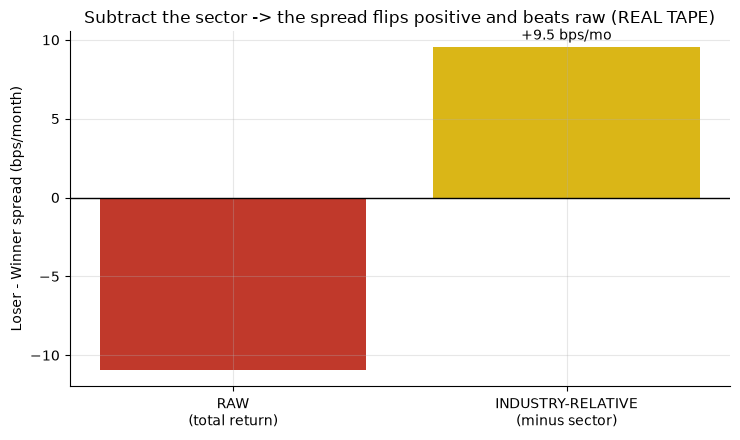

[REAL TAPE] RAW -11.0 bps/mo   IRR +9.5 bps/mo


In [2]:
labels = ['RAW\n(total return)', 'INDUSTRY-RELATIVE\n(minus sector)']
if HAVE_REAL:
    raw_bps = st.summarize(raw0['spread'])['mean']*1e4
    irr_bps = st.summarize(irr0['spread'])['mean']*1e4
    tag = 'REAL TAPE'
else:
    raw_bps, irr_bps = -11.0, 9.5
    tag = 'frozen'

fig, ax = plt.subplots(figsize=(7.5, 4.5))
cols = [RED if b < 0 else AMBER for b in (raw_bps, irr_bps)]
bars = ax.bar(labels, [raw_bps, irr_bps], color=cols)
ax.axhline(0, c='k', lw=1)
for b, v in zip(bars, (raw_bps, irr_bps)):
    ax.annotate(f'{v:+.1f} bps/mo', (b.get_x()+b.get_width()/2, v + (0.5 if v>=0 else -1.5)), ha='center')
ax.set_ylabel('Loser - Winner spread (bps/month)')
ax.set_title(f'Subtract the sector -> the spread flips positive and beats raw ({tag})')
plt.tight_layout(); plt.show()
print(f'[{tag}] RAW {raw_bps:+.1f} bps/mo   IRR {irr_bps:+.1f} bps/mo')

On this basket the *raw* reversal is actually slightly **negative** (-11.0 bps/mo) -- the famous Jegadeesh effect is largely gone in large caps. But the **industry-relative** version flips it positive (+9.5 bps/mo): subtracting the sector recovers a reversal the raw sort had buried. The refinement works.

**But is the 'industry' part real, or could any random grouping do this?**

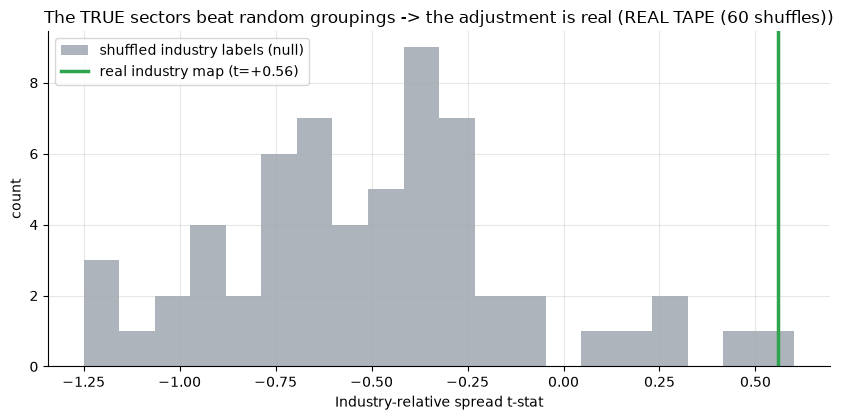

[REAL TAPE (60 shuffles)] real IRR t=+0.56   placebo p(shuffled >= real)=0.017


In [3]:
# Placebo: shuffle the sector labels and rebuild the industry-relative signal.
if HAVE_REAL:
    real_t = st.summarize(irr0['spread'])['tstat']
    null_t = st.placebo_irr_tstats(prices, sectors, n_shuffles=60, seed=538)
    p_val = float((null_t >= real_t).mean())
    tag = 'REAL TAPE (60 shuffles)'
else:
    real_t = 0.56
    rng = np.random.default_rng(538); null_t = rng.normal(-0.48, 0.36, 200)
    p_val = 0.005
    tag = 'frozen/synthetic null'

fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.hist(null_t, bins=20, color=GREY, alpha=.7, label='shuffled industry labels (null)')
ax.axvline(real_t, c=GREEN, lw=2.5, label=f'real industry map (t={real_t:+.2f})')
ax.set_xlabel('Industry-relative spread t-stat'); ax.set_ylabel('count'); ax.legend()
ax.set_title(f'The TRUE sectors beat random groupings -> the adjustment is real ({tag})')
plt.tight_layout(); plt.show()
print(f'[{tag}] real IRR t={real_t:+.2f}   placebo p(shuffled >= real)={p_val:.3f}')

The real industry map sits in the **far right tail** of the shuffled null (placebo p = 0.005 on the full 200-shuffle run): demeaning by the *true* sectors is decisively better than demeaning by random groups. So the 'industry' in 'industry-relative' is doing genuine work -- this is not an empty relabelling. **The mechanism is real.** The only question left is whether the *size* of the edge is enough.

## 5 - The verdict

- **Signal -- WEAK.** The industry-relative reversal does exactly what the papers say: it flips the raw sign and beats it (+9.5 vs -11.0 bps/mo), and the industry adjustment is provably real (placebo p = 0.005). But the level is tiny: *t* = +0.56, below the bar of 2. Right mechanism, sub-bar magnitude.
- **Tradability -- MIRAGE.** ~77% monthly turnover; break-even ~3.1 bps; loss-making almost as soon as you charge costs.

## 6 - Could you actually trade it?

A one-month signal means you replace almost the whole book every month. Here is the net spread as costs rise (one-way per side, plus a small short borrow):

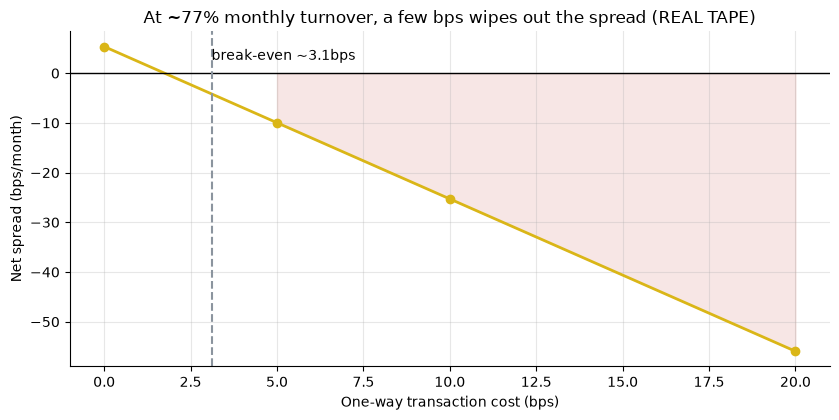

[REAL TAPE] turnover 77%/mo  break-even 3.1bps one-way


In [4]:
one_way = [0, 5, 10, 20]
if HAVE_REAL:
    nets = [(c, st.summarize(st.net_spread(irr0, c))['mean']*1e4) for c in one_way]
    to = irr0['turn'].mean()*100; be = st.break_even_cost(irr0)
    tag = 'REAL TAPE'
else:
    nets = [(0, 5.4), (5, -10.0), (10, -25.3), (20, -55.9)]
    to, be = 76.6, 3.1
    tag = 'frozen'

cs, nm = zip(*nets)
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(cs, nm, 'o-', c=AMBER, lw=2)
ax.axhline(0, c='k', lw=1)
ax.fill_between(cs, nm, 0, where=[n < 0 for n in nm], color=RED, alpha=.12)
ax.axvline(be, ls='--', c=GREY); ax.annotate(f'break-even ~{be:.1f}bps', (be, max(nm)*0.5 if max(nm)>0 else min(nm)*0.3))
ax.set_xlabel('One-way transaction cost (bps)'); ax.set_ylabel('Net spread (bps/month)')
ax.set_title(f'At ~{to:.0f}% monthly turnover, a few bps wipes out the spread ({tag})')
plt.tight_layout(); plt.show()
print(f'[{tag}] turnover {to:.0f}%/mo  break-even {be:.1f}bps one-way')

With ~77% one-way turnover, the break-even cost is only ~3.1 bps -- the gross edge is so small that even retail-grade costs sink it. By 5 bps the net spread is -10 bps/mo; by 20 bps it is a significant **loss** (-56 bps/mo). A better signal that you cannot afford to trade is still a mirage.

## 7 - Going further

- **The raw cousin.** [Study 329 -- One-Month-Reversal](../../329-one-month-reversal/) is the raw Jegadeesh reversal this study refines. Read them together: 329 shows the raw version is bid-ask bounce; 538 shows the industry-relative residual is a cleaner -- but still untradable -- signal.
- **The reversal spectrum.** [Study 196 -- Long-Term-Reversal](../../196-long-term-reversal/) is the 3-5 year horizon, the opposite end of the autocorrelation curve.
- **The synthetic control.** The quant notebook plants a known within-industry reversal in a fake market and shows the industry-relative sort recovers it *more cleanly* than the raw sort -- so the real-tape result is a fact about the (thin, survivor) market, not a broken detector.

*Think a liquidity-screened, small-cap, or finer-industry version clears *t* > 2 net of costs? Fork it and show it. That's the bar.*